X1 shape after df_to_X_y: (971, 5) y1 shape: (971,)
Train shapes: (800, 5) (800,)
Validation shapes: (100, 5) (100,)
Test shapes: (71, 5) (71,)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 4.6873 - root_mean_squared_error: 2.1635 - val_loss: 5.4129 - val_root_mean_squared_error: 2.3266
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.5546 - root_mean_squared_error: 1.8845 - val_loss: 3.0874 - val_root_mean_squared_error: 1.7571
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8113 - root_mean_squared_error: 1.3355 - val_loss: 0.6987 - val_root_mean_squared_error: 0.8359
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7146 - root_mean_squared_error: 0.8453 - val_loss: 0.5589 - val_root_mean_squared_error: 0.7476
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7171 - root_mean_squared_error: 0.8467 - val_loss: 0.6080 - val_root_mean_squared_error: 0.7797
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6614 - root_mean_squared_error: 0.8132 - val_loss: 0.5593 - val_root_mean_squared_error: 0.7478
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss

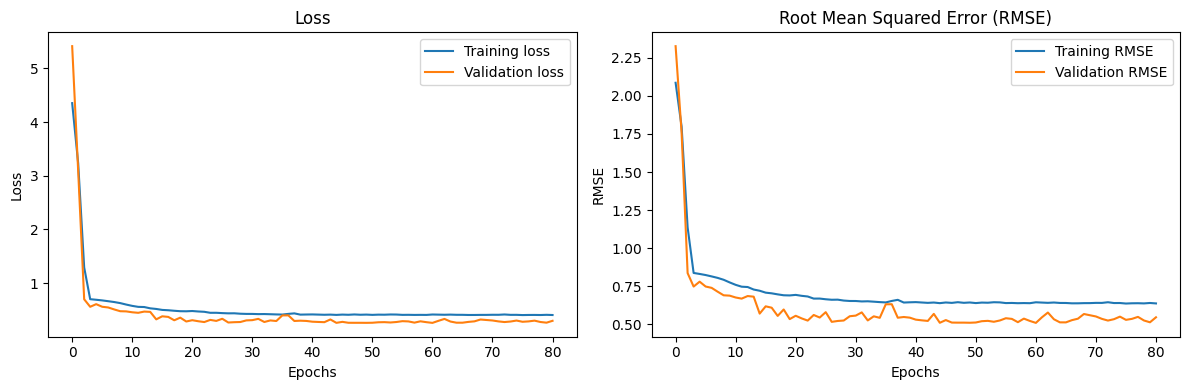

Model input shape: (None, 5, 1)


In [15]:
import os
import pandas as pd
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score

df = pd.read_csv("emotiv_no_ohe.csv")
df

# ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).set_output(transform="pandas")

# ohetransform = ohe.fit_transform(df[['Command']])
# ohetransform

# df = df.drop(columns=['Command'])
# df

# df = pd.concat([df, ohetransform], axis = 1)
# df

def df_to_X_y(df, window_size=5):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [a for a in df_as_np[i:i+window_size]]  # Removed the additional [] around each element
    X.append(row)
    label = df_as_np[i+window_size]
    y.append(label)
  return np.array(X), np.array(y)

com = df['Command']
WINDOW_SIZE = 5
X1, y1 = df_to_X_y(com, WINDOW_SIZE)
print("X1 shape after df_to_X_y:", X1.shape, "y1 shape:", y1.shape)

X_train1, y_train1 = X1[:800], y1[:800] #First rows
X_val1, y_val1 = X1[800:900], y1[800:900] #row range
X_test1, y_test1 = X1[900:], y1[900:] #the rest
print("Train shapes:", X_train1.shape, y_train1.shape)
print("Validation shapes:", X_val1.shape, y_val1.shape)
print("Test shapes:", X_test1.shape, y_test1.shape)

# No need to reshape as our data is already in the correct shape (samples, timesteps, features)
# where features = 1 since we're only using the 'Command' column

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

model1 = Sequential()
model1.add(InputLayer((WINDOW_SIZE, 1)))  # Input shape: (timesteps, features)
model1.add(LSTM(64, return_sequences=False))
model1.add(Dense(8, activation='relu'))
model1.add(Dense(1, activation='linear'))

model1.summary()

early_stopping = EarlyStopping(patience=20, restore_best_weights=True)
cp1 = ModelCheckpoint('model1.keras', save_best_only=True)

model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.001), metrics=[RootMeanSquaredError()]) 
history = model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=100, callbacks=[cp1, early_stopping])

# Evaluate the model on the test set
y_pred_test = model1.predict(X_test1)
y_pred_test_rounded = np.round(y_pred_test).astype(int)  # Round predictions to nearest integer
accuracy = accuracy_score(y_test1, y_pred_test_rounded)
print("Test accuracy:", accuracy)

# Plot loss and accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(12,
4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['root_mean_squared_error'], label='Training RMSE')
plt.plot(history.history['val_root_mean_squared_error'], label='Validation RMSE')
plt.title('Root Mean Squared Error (RMSE)')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.legend()

plt.tight_layout()
plt.show()

input_shape = model1.input_shape
print("Model input shape:", input_shape)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


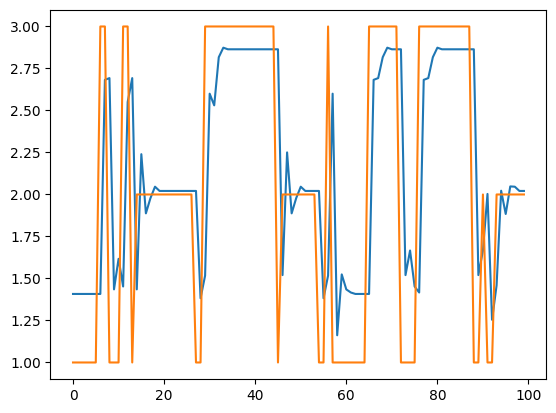

In [16]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

model1 = load_model('model1.keras')

train_predictions = model1.predict(X_train1).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train1})
train_results

plt.plot(train_results['Train Predictions'][:100]) #Zoom in and out first results
plt.plot(train_results['Actuals'][:100])

In [17]:
train_results

,Train Predictions,Actuals
0,1.407893,1
1,1.407893,1
2,1.407893,1
3,1.407893,1
4,1.407893,1
...,...,...
795,1.851332,2
796,2.047964,2
797,2.046270,2
798,2.021059,2


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


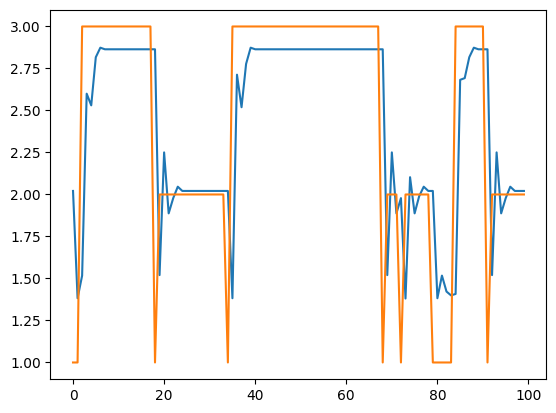

In [18]:
val_predictions = model1.predict(X_val1).flatten()
val_results = pd.DataFrame(data={'Val Predictions':val_predictions, 'Actuals':y_val1})
val_results

plt.plot(val_results['Val Predictions'][:100])
plt.plot(val_results['Actuals'][:100])

In [19]:
test_predictions = model1.predict(X_test1).flatten()
test_predictions = np.round(test_predictions)
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test1})
test_results
# plt.plot(test_results['Test Predictions'][:100])
# plt.plot(test_results['Actuals'][:100])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,Test Predictions,Actuals
0,2.0,2
1,2.0,2
2,2.0,2
3,2.0,2
4,2.0,2
...,...,...
66,3.0,3
67,3.0,1
68,2.0,1
69,2.0,1


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5170 - root_mean_squared_error: 0.7189  
Accuracy: 0.7159219980239868
Accuracy: 71.59219980239868


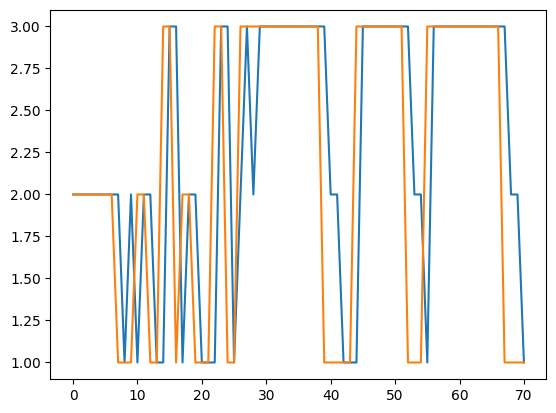

In [20]:
y_pred = model1.predict(X_test1).flatten()
accuracy = model1.evaluate(X_test1, y_test1)[1]
print("Accuracy:", accuracy)
print("Accuracy:", accuracy * 100)

plt.plot(test_results['Test Predictions'][:200])
plt.plot(test_results['Actuals'][:200])